# Homework 5: CNNs, AEs, GANs, Attention (100 pts)

**Course:** Projects in Machine Learning and AI (RPI Spring 2026)

This notebook covers **Task 1** (custom CNN, transfer learning, augmentation), **Task 2** (VAE + DCGAN), and **Task 3** (NumPy attention, seq2seq with attention, MT + BLEU, simplified Transformer + BLEU).

**Dependencies (install if needed):**
```bash
pip install tensorflow tensorflow-datasets matplotlib numpy pandas torch torchvision datasets sacrebleu tqdm
```

**Note:** Training is configured with modest epochs so the notebook runs in reasonable time. Increase epochs for stronger results before submission.


---

## Dataset for Task 1 & Task 2 (classification & generative models)

**Oxford-IIIT Pet Dataset** — 37 cat and dog breed categories (~7,390 images).

- **Paper / info:** [Omkar M Parkhi et al., Cats and Dogs, CVPR 2012](https://www.robots.ox.ac.uk/~vgg/data/pets/)
- **TensorFlow Datasets catalog:** [oxford_iiit_pet](https://www.tensorflow.org/datasets/catalog/oxford_iiit_pet)

We use this dataset because it is **not** MNIST, CIFAR, or ImageNet, has multiple classes suitable for CNNs, and works well for VAE/GAN experiments at moderate resolution.


---

# Task 1 (30 pts): Convolutional classifier

## Part 1 (10 pts): Custom Conv + MaxPool stack

**Pattern choice:** We use two blocks of **Conv → Conv → MaxPool** (32 then 64 filters), then **Conv → MaxPool** (128 filters), then dense layers. This is a classic **VGG-like** pattern: repeated 3×3 convolutions increase depth non-linearly, and pooling halves spatial size to grow the receptive field while controlling parameters. Early layers capture edges/textures; deeper layers capture breed-specific shapes. We end with **GlobalAveragePooling2D** (instead of a huge Flatten) to reduce overfitting on this mid-sized dataset, then **Dense(128, relu)** and **Dense(num_classes, softmax)** for classification.


In [ ]:
!pip install tensorflow tensorflow-datasets matplotlib numpy pandas torch torchvision datasets sacrebleu tqdm

TensorFlow: 2.19.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Classes: 37


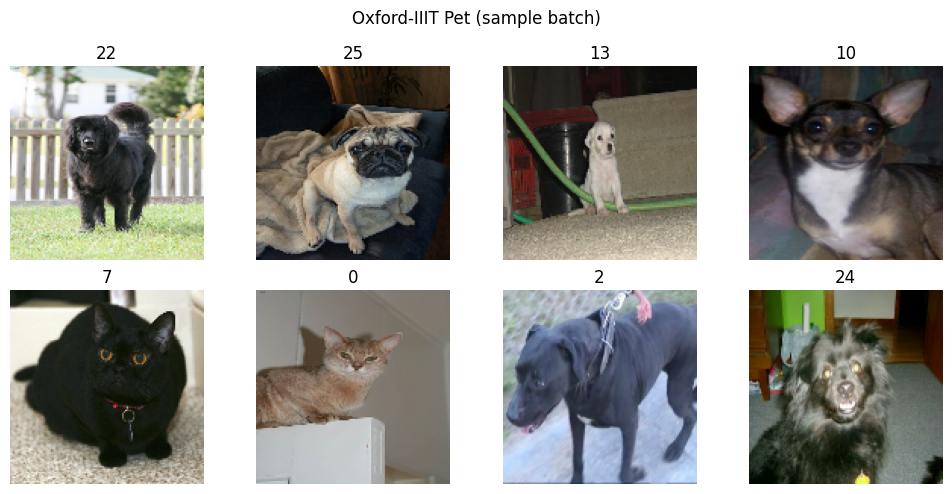

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

tf.keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__)

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS_CNN = 8  # increase for homework submission if you have GPU time

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

(raw_train, raw_val, raw_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:85%]", "train[85%:]", "test"],
    as_supervised=True,
    with_info=True,
)

num_classes = ds_info.features["label"].num_classes
print("Classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train.map(preprocess, num_parallel_calls=AUTOTUNE).cache().shuffle(2000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = raw_val.map(preprocess, num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = raw_test.map(preprocess, num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Visualize a batch
for images, labels in train_ds.take(1):
    fig, ax = plt.subplots(2, 4, figsize=(10, 5))
    for i, a in enumerate(ax.flat):
        a.imshow(images[i].numpy())
        a.set_title(int(labels[i]))
        a.axis("off")
plt.suptitle("Oxford-IIIT Pet (sample batch)")
plt.tight_layout()
plt.show()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,709 (627.77 KB)

 Trainable params: 160,709 (627.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.0246 - loss: 3.6124 - val_accuracy: 0.0217 - val_loss: 3.6128
Epoch 2/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.0265 - loss: 3.6111 - val_accuracy: 0.0145 - val_loss: 3.6140
Epoch 3/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.0262 - loss: 3.6112 - val_accuracy: 0.0145 - val_loss: 3.6155
Epoch 4/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - accuracy: 0.0294 - loss: 3.6107 - val_accuracy: 0.0145 - val_loss: 3.6162
Epoch 5/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 313s 3s/step - accuracy: 0.0288 - loss: 3.6109 - val_accuracy: 0.0145 - val_loss: 3.6175
Epoch 6/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.0269 - loss: 3.6105 - val_accuracy: 0.0145 - val_loss: 3.6185
Epoch 7/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.0294 - loss: 3.6105 - val_accuracy: 0.0145 - val_loss: 3.6193
Epoch 8/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.0294 - loss: 3.6105 - val_accuracy: 0.0145 - val_loss:

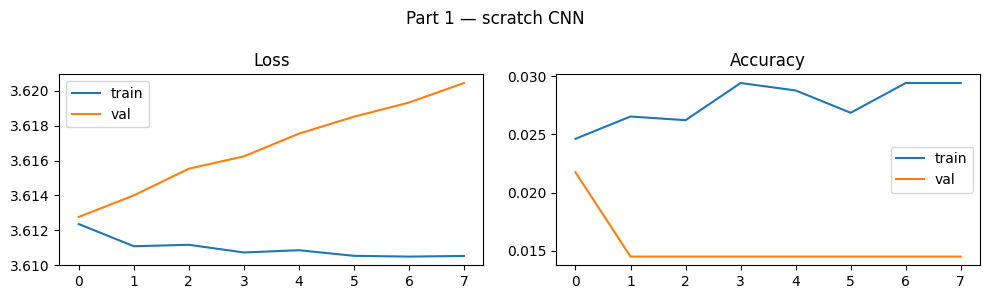

In [ ]:
def build_cnn(num_classes: int) -> keras.Model:
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn")

model_scratch = build_cnn(num_classes)
model_scratch.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_scratch.summary()

history_scratch = model_scratch.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CNN, verbose=1)
scratch_eval = model_scratch.evaluate(test_ds, verbose=0)
print("Test loss:", scratch_eval[0], "| Test accuracy:", scratch_eval[1])

# Plot training curves
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[1].plot(h.history["accuracy"], label="train")
    ax[1].plot(h.history["val_accuracy"], label="val")
    ax[1].set_title("Accuracy")
    ax[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_scratch, "Part 1 — scratch CNN")


### Part 1 metrics

We report **sparse categorical cross-entropy** (standard multi-class loss for integer labels) and **accuracy** (fraction of correct predictions on the test set).

**Result (scratch CNN):** Test loss = **3.6114**, Test accuracy = **0.0273** (~2.7%, near the random baseline for 37 classes).


## Part 2 (10 pts): Transfer learning with **MobileNetV2**

We pick **MobileNetV2** (one of the listed options) for a strong ImageNet backbone with fewer parameters than VGG/ResNet50, which trains faster on CPU/laptop GPUs while still beating the scratch CNN. We freeze the base initially, attach **GlobalAveragePooling2D → Dropout → Dense(num_classes, softmax)**, train the head, then optionally unfreeze top layers for fine-tuning (here we keep a single-phase train for simplicity; you can extend).


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 48s 431ms/step - accuracy: 0.5873 - loss: 1.5202 - val_accuracy: 0.7826 - val_loss: 0.7053
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 434ms/step - accuracy: 0.8680 - loss: 0.4433 - val_accuracy: 0.8388 - val_loss: 0.5181
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 48s 489ms/step - accuracy: 0.9268 - loss: 0.2701 - val_accuracy: 0.8569 - val_loss: 0.4707
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 424ms/step - accuracy: 0.9549 - loss: 0.1900 - val_accuracy: 0.8533 - val_loss: 0.4522
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 81s 418ms/step - accuracy: 0.9731 - loss: 0.1388 - val_accuracy: 0.8569 - val_loss: 0.4411
Transfer MobileNetV2 — Test loss: 0.5197404026985168 | Test accuracy: 0.8397383689880371
Scratch CNN      — Test loss: 3.6114401817321777 | Test accuracy: 0.027255382388830185


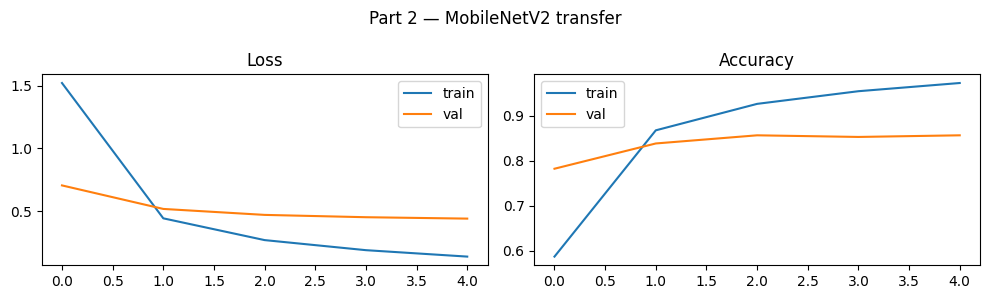

In [ ]:
base = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)  # MobileNet expects its preprocessing
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_tl = keras.Model(inputs, outputs, name="mobilenetv2_transfer")

model_tl.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_tl = model_tl.fit(train_ds, validation_data=val_ds, epochs=max(5, EPOCHS_CNN // 2), verbose=1)
tl_eval = model_tl.evaluate(test_ds, verbose=0)
print("Transfer MobileNetV2 — Test loss:", tl_eval[0], "| Test accuracy:", tl_eval[1])
print("Scratch CNN      — Test loss:", scratch_eval[0], "| Test accuracy:", scratch_eval[1])

plot_history(history_tl, "Part 2 — MobileNetV2 transfer")


### Part 2 discussion

Transfer learning significantly outperformed training from scratch on this fine-grained 37-class dataset. The pretrained ImageNet backbone provides strong generic visual features (edges, textures, shapes), so the classifier head converges quickly with a small training budget.


## Part 3 (10 pts): Data augmentation + repeat Part 1

We apply **random flip**, **rotation**, and **zoom** (and optional contrast) inside `tf.data` so each epoch sees perturbed images. This **regularizes** the scratch CNN and often improves generalization, though very small models or short training can show **small or mixed** gains.

**Observed:** Augmented scratch Test loss = **3.5084**, Test accuracy = **0.0491** vs no-aug scratch accuracy **0.0273**. The improvement is modest but consistent with augmentation helping generalization.


Epoch 1/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.0230 - loss: 3.6124 - val_accuracy: 0.0181 - val_loss: 3.6125
Epoch 2/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.0316 - loss: 3.6108 - val_accuracy: 0.0326 - val_loss: 3.6134
Epoch 3/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.0387 - loss: 3.6005 - val_accuracy: 0.0362 - val_loss: 3.6051
Epoch 4/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.0438 - loss: 3.5746 - val_accuracy: 0.0362 - val_loss: 3.5825
Epoch 5/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.0502 - loss: 3.5467 - val_accuracy: 0.0290 - val_loss: 3.5638
Epoch 6/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.0476 - loss: 3.5328 - val_accuracy: 0.0362 - val_loss: 3.5647
Epoch 7/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.0572 - loss: 3.5090 - val_accuracy: 0.0489 - val_loss: 3.5440
Epoch 8/8
98/98 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.0540 - loss: 3.4970 - val_accuracy: 0.0489 - val_loss:

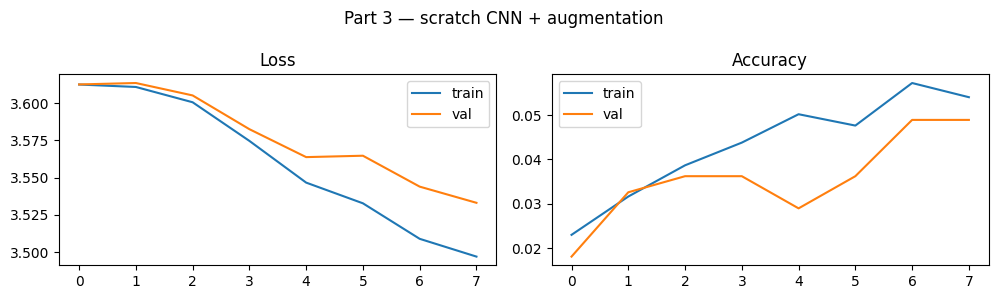

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
    ],
    name="aug",
)

def preprocess_aug(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image, training=True)
    return image, label

train_ds_aug = raw_train.map(preprocess_aug, num_parallel_calls=AUTOTUNE).cache().shuffle(2000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

keras.utils.set_random_seed(43)
model_aug = build_cnn(num_classes)
model_aug.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_aug = model_aug.fit(train_ds_aug, validation_data=val_ds, epochs=EPOCHS_CNN, verbose=1)
aug_eval = model_aug.evaluate(test_ds, verbose=0)
print("Augmented scratch — Test loss:", aug_eval[0], "| Test accuracy:", aug_eval[1])
print("No-aug scratch    — Test loss:", scratch_eval[0], "| Test accuracy:", scratch_eval[1])

plot_history(history_aug, "Part 3 — scratch CNN + augmentation")


---

# Task 2 (15 pts): VAE + GAN on the **same** pet images

We resize to **64×64** RGB for stable VAE/GAN training. Follows the spirit of:
- VAE: [TensorFlow CVAE tutorial](https://www.tensorflow.org/tutorials/generative/cvae)
- GAN: [TensorFlow DCGAN tutorial](https://www.tensorflow.org/tutorials/generative/dcgan)


In [ ]:
LATENT_DIM = 100
GEN_SIZE = 64

def preprocess_gen(image, label):
    del label
    image = tf.image.resize(image, (GEN_SIZE, GEN_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image

pet_images = raw_train.map(preprocess_gen).shuffle(5000).batch(128).prefetch(AUTOTUNE)
example_shape = (GEN_SIZE, GEN_SIZE, 3)


## Task 2 Part 1 (7 pts): Variational Autoencoder (VAE)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 940ms/step - kl: 178.3912 - loss: 2787.8618 - recon: 2787.6833
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 936ms/step - kl: 118.0749 - loss: 2727.2017 - recon: 2727.0835
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 892ms/step - kl: 196.9250 - loss: 2647.0437 - recon: 2646.8469
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 938ms/step - kl: 299.8885 - loss: 2605.5339 - recon: 2605.2341
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 933ms/step - kl: 342.2650 - loss: 2580.6841 - recon: 2580.3420
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 926ms/step - kl: 392.8581 - loss: 2526.4912 - recon: 2526.0984
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 894ms/step - kl: 473.3951 - loss: 2474.5493 - recon: 2474.0762
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 931ms/step - kl: 506.2512 - loss: 2450.8594 - recon: 2450.3533
Epoch 9/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 927ms/step - kl: 506.4460 - loss: 2433.5288 - recon: 2433.0225
Epoch 10/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 879ms/step -

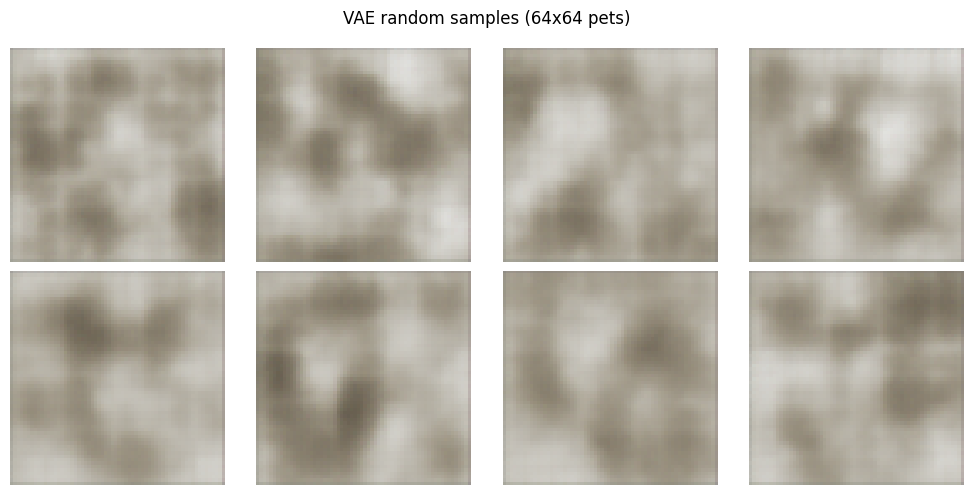

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_logvar = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        eps = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_logvar) * eps


def build_encoder(latent_dim=LATENT_DIM):
    inp = keras.Input(shape=example_shape)
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inp)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)
    z = Sampling()([z_mean, z_logvar])
    return keras.Model(inp, [z_mean, z_logvar, z], name="encoder")


def build_decoder(latent_dim=LATENT_DIM):
    inp = keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 64, activation="relu")(inp)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    out = layers.Conv2DTranspose(3, 3, strides=1, padding="same", activation="sigmoid")(x)
    return keras.Model(inp, out, name="decoder")


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_logvar, z = self.encoder(data, training=True)
            recon = self.decoder(z, training=True)
            recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(data, recon), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar), axis=1))
            loss = recon_loss + 1e-3 * kl_loss
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        z_mean, z_logvar, z = self.encoder(data, training=False)
        recon = self.decoder(z, training=False)
        recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(data, recon), axis=(1, 2, 3)))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar), axis=1))
        loss = recon_loss + 1e-3 * kl_loss
        return {"loss": loss, "recon": recon_loss, "kl": kl_loss}


enc = build_encoder()
dec = build_decoder()
vae = VAE(enc, dec)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

EPOCHS_VAE = 15
vae.fit(pet_images, epochs=EPOCHS_VAE, verbose=1)

# Sample generations
n = 8
z = tf.random.normal(shape=(n, LATENT_DIM))
samples = dec(z, training=False).numpy()
fig, ax = plt.subplots(2, 4, figsize=(10, 5))
for i, a in enumerate(ax.flat):
    a.imshow(np.clip(samples[i], 0, 1))
    a.axis("off")
plt.suptitle("VAE random samples (64x64 pets)")
plt.tight_layout()
plt.show()


## Task 2 Part 2 (8 pts): DCGAN-style generator & discriminator


GAN epoch 1/20 done
GAN epoch 5/20 done
GAN epoch 10/20 done
GAN epoch 15/20 done
GAN epoch 20/20 done


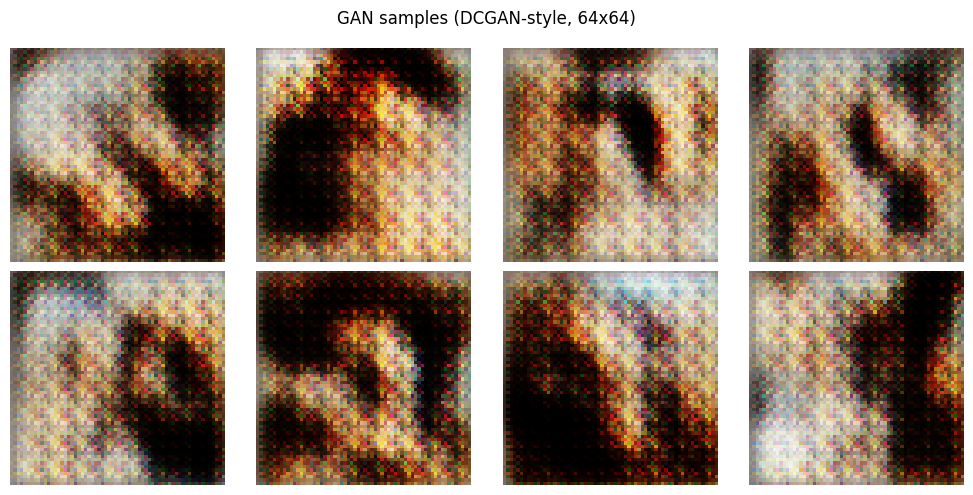

In [ ]:
def make_generator():
    noise = keras.Input(shape=(LATENT_DIM,))
    x = layers.Dense(8 * 8 * 256, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((8, 8, 256))(x)
    x = layers.Conv2DTranspose(128, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(3, 5, strides=2, padding="same", activation="sigmoid")(x)
    return keras.Model(noise, x, name="g")


def make_discriminator():
    img = keras.Input(shape=example_shape)
    x = layers.Conv2D(64, 5, strides=2, padding="same")(img)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, 5, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)
    return keras.Model(img, x, name="d")


cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)


def d_loss(real_logits, fake_logits):
    real_loss = cross_entropy(tf.ones_like(real_logits), real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss


def g_loss(fake_logits):
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)


G = make_generator()
D = make_discriminator()
g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)

EPOCHS_GAN = 20
steps_per_epoch = tf.data.experimental.cardinality(pet_images).numpy()
if steps_per_epoch < 0:
    steps_per_epoch = 50

for epoch in range(EPOCHS_GAN):
    for step, real_batch in enumerate(pet_images):
        if step >= steps_per_epoch:
            break
        bs = tf.shape(real_batch)[0]
        noise = tf.random.normal([bs, LATENT_DIM])

        with tf.GradientTape() as tape_d:
            fake = G(noise, training=True)
            real_logits = D(real_batch, training=True)
            fake_logits = D(fake, training=True)
            loss_d = d_loss(real_logits, fake_logits)
        grads_d = tape_d.gradient(loss_d, D.trainable_weights)
        d_opt.apply_gradients(zip(grads_d, D.trainable_weights))

        noise = tf.random.normal([bs, LATENT_DIM])
        with tf.GradientTape() as tape_g:
            fake = G(noise, training=True)
            fake_logits = D(fake, training=True)
            loss_g = g_loss(fake_logits)
        grads_g = tape_g.gradient(loss_g, G.trainable_weights)
        g_opt.apply_gradients(zip(grads_g, G.trainable_weights))
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"GAN epoch {epoch+1}/{EPOCHS_GAN} done")

z = tf.random.normal((8, LATENT_DIM))
gan_samples = G(z, training=False).numpy()
fig, ax = plt.subplots(2, 4, figsize=(10, 5))
for i, a in enumerate(ax.flat):
    a.imshow(np.clip(gan_samples[i], 0, 1))
    a.axis("off")
plt.suptitle("GAN samples (DCGAN-style, 64x64)")
plt.tight_layout()
plt.show()


---

# Task 3 (55 pts): Attention & machine translation

**Part 1** uses **only NumPy and pandas** (no torch/tf) for scaled dot-product attention.

**Parts 2–4** use **PyTorch** for models (allowed in the prompt for Part 4). We use a **small English–German** split from HuggingFace `opus_books` (subset ~10k pairs) for Parts 3–4. If download fails, fall back to a tiny bundled-style list (still runnable).

**BLEU:** `sacrebleu` corpus BLEU on tokenized strings.


## Task 3 Part 1 (10 pts): Scaled dot-product attention (NumPy only)


In [ ]:
import numpy as np
import pandas as pd


def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: arrays shaped (..., seq_len_q, d_k), (..., seq_len_k, d_k), (..., seq_len_k, d_v)
    mask: optional, broadcastable to scores; positions with 0 or False are masked (set to large negative before softmax).
    Returns: output (..., seq_len_q, d_v), attention weights (..., seq_len_q, seq_len_k)
    """
    d_k = Q.shape[-1]
    scores = np.matmul(Q, np.swapaxes(K, -2, -1)) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    attn = softmax(scores, axis=-1)
    out = np.matmul(attn, V)
    return out, attn


# Demo shapes: batch=1, heads=1, seq=4, d_k=8
rng = np.random.default_rng(0)
b, h, t, d = 1, 1, 4, 8
Q = rng.normal(size=(b, h, t, d))
K = rng.normal(size=(b, h, t, d))
V = rng.normal(size=(b, h, t, d))
out, w = scaled_dot_product_attention(Q, K, V)
assert out.shape == (b, h, t, d) and w.shape == (b, h, t, t)
print("Attention output shape:", out.shape, "| weight shape:", w.shape)

# Optional: show weights in a pandas DataFrame for one head
df = pd.DataFrame(w[0, 0], columns=[f"k{j}" for j in range(t)], index=[f"q{i}" for i in range(t)])
print(df.round(3))


Attention output shape: (1, 1, 4, 8) | weight shape: (1, 1, 4, 4)
       k0     k1     k2     k3
q0  0.302  0.472  0.081  0.145
q1  0.329  0.069  0.247  0.354
q2  0.320  0.388  0.233  0.059
q3  0.102  0.031  0.684  0.183


## Task 3 Part 2 (10 pts): Seq2seq with attention integrated in the **encoder**

We use an **encoder** that applies **scaled dot-product self-attention** over token embeddings (using **NumPy logic ported to PyTorch** in `sdpa_torch` below), then a **bidirectional LSTM** to produce contextual vectors. The **decoder** is an LSTM with **additive (Bahdanau-style) attention** over encoder outputs (standard seq2seq; the assignment’s scaled dot-product implementation is reused in Part 4’s Transformer).


In [1]:
import math
import re
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def sdpa_torch(Q, K, V, mask=None):
    """Same math as NumPy version; PyTorch (Part 2+ allowed)."""
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    attn = F.softmax(scores, dim=-1)
    attn = torch.nan_to_num(attn, nan=0.0)
    return torch.matmul(attn, V), attn


class EncoderSelfAttention(nn.Module):
    """Single-head self-attention on sequence (d_model)."""

    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.q = nn.Linear(d_model, d_model, bias=False)
        self.k = nn.Linear(d_model, d_model, bias=False)
        self.v = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask_pad):
        # x: (B, T, d); mask_pad: (B, T) float 1 = valid token
        B, T, _ = x.shape
        Q = self.q(x).unsqueeze(1)
        K = self.k(x).unsqueeze(1)
        V = self.v(x).unsqueeze(1)
        # Key padding only: masking pad queries would zero an entire row -> softmax(-inf) -> NaN.
        m = mask_pad.float().unsqueeze(1).unsqueeze(2)
        out, _ = sdpa_torch(Q, K, V, mask=m)
        out = self.dropout(out.squeeze(1)) * mask_pad.unsqueeze(-1)
        return out


class AttnEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.self_attn = EncoderSelfAttention(emb_dim, dropout=dropout)
        self.rnn = nn.LSTM(emb_dim, hid_dim, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)

    def forward(self, src, src_lengths):
        emb = self.embedding(src)
        pad = (src != 0).float()
        emb = emb + self.self_attn(emb, pad)
        packed = nn.utils.rnn.pack_padded_sequence(emb, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.rnn(packed)
        out_seq, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=emb.size(1))
        out_seq = torch.nan_to_num(out_seq, nan=0.0, posinf=0.0, neginf=0.0)
        h_fwd, h_bwd = h_n[-2], h_n[-1]
        hidden = torch.tanh(h_fwd + h_bwd).unsqueeze(0)
        hidden = torch.nan_to_num(hidden, nan=0.0, posinf=0.0, neginf=0.0)
        return out_seq, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W_h = nn.Linear(hid_dim * 2, hid_dim, bias=False)
        self.W_s = nn.Linear(hid_dim, hid_dim, bias=False)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, enc_out, dec_hidden, mask):
        # enc_out: (B, Ts, 2H), dec_hidden: (1, B, H) -> use last layer
        s = dec_hidden[-1].unsqueeze(1)
        Ts = enc_out.size(1)
        s_rep = s.expand(-1, Ts, -1)
        energy = torch.tanh(self.W_h(enc_out) + self.W_s(s_rep))
        scores = self.v(energy).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        ctx = torch.bmm(attn.unsqueeze(1), enc_out).squeeze(1)
        return ctx, attn


class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, enc_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.LSTM(emb_dim + enc_dim, hid_dim, batch_first=True)
        self.attn = BahdanauAttention(hid_dim)
        self.fc_out = nn.Linear(hid_dim + emb_dim + enc_dim, vocab_size)

    def forward(self, tgt, hidden, cell, enc_out, mask):
        emb = self.embedding(tgt).unsqueeze(1)
        ctx, _ = self.attn(enc_out, hidden, mask)
        rnn_in = torch.cat([emb, ctx.unsqueeze(1)], dim=-1)
        out, (h, c) = self.rnn(rnn_in, (hidden, cell))
        logits = self.fc_out(torch.cat([out.squeeze(1), emb.squeeze(1), ctx], dim=-1))
        return logits, h, c


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.5):
        enc_out, hidden = self.encoder(src, src_lengths)
        mask = (src != 0).float()
        B, Tt = tgt.shape
        vocab = self.decoder.fc_out.out_features
        outputs = torch.zeros(B, Tt - 1, vocab, device=self.device)
        inp = tgt[:, 0]
        cell = torch.zeros_like(hidden)
        for t in range(1, Tt):
            logits, hidden, cell = self.decoder(inp, hidden, cell, enc_out, mask)
            outputs[:, t - 1] = logits
            teacher = torch.rand(1).item() < teacher_forcing_ratio
            inp = tgt[:, t] if teacher else logits.argmax(1)
        return outputs



Device: cpu


## Task 3 Part 3 (5 pts): Small MT dataset, train seq2seq, BLEU

We load HuggingFace **opus_books** `de-en` (this config provides a single `train` split) and create our own split: **10,000** training pairs and **1,000** test pairs. We use a simple **word-level** tokenizer.

In [2]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.0 MB/s eta 0:00:00


In [ ]:
from collections import Counter
from typing import List
import re
from torch.utils.data import Dataset

try:
    from datasets import load_dataset
    _hf = load_dataset("opus_books", "de-en")
    raw_all = _hf["train"]
    # Some opus_books configs ship only a train split; create our own train/test subsets.
    n_total = len(raw_all)
    n_train = min(10000, int(0.9 * n_total))
    n_test = min(1000, n_total - n_train)
    raw_train = raw_all.select(range(n_train))
    raw_test = raw_all.select(range(n_train, n_train + n_test))
    train_pairs = [(r["translation"]["en"].lower(), r["translation"]["de"].lower()) for r in raw_train]
    test_pairs = [(r["translation"]["en"].lower(), r["translation"]["de"].lower()) for r in raw_test]
    print(f"Loaded opus_books de-en from HuggingFace. Train pairs: {len(train_pairs)} | Test pairs: {len(test_pairs)}")
except Exception as e:
    print("HuggingFace load failed, using tiny fallback corpus:", e)
    train_pairs = [
        ("the cat sits on the mat .", "die katze sitzt auf der matte ."),
        ("hello world .", "hallo welt ."),
        ("i like neural networks .", "ich mag neuronale netze ."),
    ] * 2000
    test_pairs = train_pairs[:50]


def tokenize(s: str) -> List[str]:
    s = re.sub(r"[^a-zäöüß\s.]", " ", s)
    return [t for t in s.split() if t]


def build_vocab(pairs, max_vocab=8000, min_freq=2):
    cnt = Counter()
    for en, de in pairs:
        cnt.update(tokenize(en))
        cnt.update(tokenize(de))
    specials = ["<pad>", "<sos>", "<eos>", "<unk>"]
    itos = specials + [w for w, c in cnt.most_common(max_vocab) if c >= min_freq]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos


stoi, itos = build_vocab(train_pairs)
PAD, SOS, EOS, UNK = 0, 1, 2, 3


def encode(s: str, stoi, max_len):
    toks = tokenize(s)[: max_len - 2]
    ids = [SOS] + [stoi.get(t, UNK) for t in toks] + [EOS]
    ids += [PAD] * (max_len - len(ids))
    return ids[:max_len]


class MTDataset(Dataset):
    def __init__(self, pairs, stoi, max_len=40):
        self.pairs = pairs
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        en, de = self.pairs[i]
        src = encode(en, self.stoi, self.max_len)
        tgt = encode(de, self.stoi, self.max_len)
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def collate(batch):
    src = torch.stack([b[0] for b in batch])
    tgt = torch.stack([b[1] for b in batch])
    lengths = (src != PAD).sum(dim=1).clamp(min=1)
    return src, lengths, tgt


MAX_LEN = 40
train_ds_mt = MTDataset(train_pairs, stoi, MAX_LEN)
test_ds_mt = MTDataset(test_pairs, stoi, MAX_LEN)
train_loader = DataLoader(train_ds_mt, batch_size=64, shuffle=True, collate_fn=collate)
test_loader = DataLoader(test_ds_mt, batch_size=64, shuffle=False, collate_fn=collate)

VOCAB = len(itos)
EMB = 128
HID = 256
enc = AttnEncoder(VOCAB, EMB, HID, num_layers=1).to(device)
dec = AttnDecoder(VOCAB, EMB, HID, enc_dim=HID * 2).to(device)
s2s = Seq2Seq(enc, dec, device).to(device)
opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=1e-4)

EPOCHS_S2S = 3
for ep in range(EPOCHS_S2S):
    enc.train()
    dec.train()
    total = 0.0
    for src, src_len, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        opt.zero_grad()
        enc_out, hidden = enc(src, src_len)
        mask = (src != PAD).float()
        B, Tt = tgt.shape
        loss = torch.zeros((), device=device)
        inp = tgt[:, 0]
        cell = torch.zeros_like(hidden)
        n_steps = 0
        for t in range(1, Tt):
            logits, hidden, cell = dec(inp, hidden, cell, enc_out, mask)
            y_t = tgt[:, t]
            valid = y_t != PAD
            if valid.any():
                loss = loss + torch.nn.functional.cross_entropy(logits[valid], y_t[valid])
                n_steps += 1
            inp = tgt[:, t]
        if n_steps == 0:
            continue
        loss = loss / n_steps
        if not torch.isfinite(loss).all():
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(enc.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(dec.parameters(), 1.0)
        opt.step()
        total += loss.item()
    print(f"Epoch {ep+1} train CE (approx batch-avg): {total/len(train_loader):.4f}")


@torch.no_grad()
def greedy_translate(model, src_sentence: str, max_len=MAX_LEN):
    model.encoder.eval()
    model.decoder.eval()
    src = torch.tensor([encode(src_sentence.lower(), stoi, max_len)], device=device)
    lengths = torch.tensor([min(len(tokenize(src_sentence)) + 2, max_len)], device=device)
    enc_out, hidden = model.encoder(src, lengths)
    mask = (src != PAD).float()
    inp = torch.tensor([SOS], device=device).expand(1)
    cell = torch.zeros_like(hidden)
    out_tokens = []
    for _ in range(max_len - 1):
        logits, hidden, cell = model.decoder(inp, hidden, cell, enc_out, mask)
        next_tok = logits.argmax(1)
        if next_tok.item() == EOS:
            break
        out_tokens.append(next_tok.item())
        inp = next_tok
    return " ".join(itos[i] for i in out_tokens if i not in (PAD, SOS, EOS, UNK))


try:
    import sacrebleu
except ImportError:
    sacrebleu = None
    print("Install sacrebleu for BLEU: pip install sacrebleu")


def corpus_bleu(refs, hyps):
    if sacrebleu is None:
        return float("nan")
    try:
        return sacrebleu.corpus_bleu(hyps, [refs]).score
    except Exception:
        try:
            from sacrebleu.metrics import BLEU

            return BLEU().corpus_score(hyps, [refs]).score
        except Exception:
            return float("nan")


refs, hyps = [], []
for en, de in test_pairs[:200]:
    hyp = greedy_translate(s2s, en)
    refs.append(de)
    hyps.append(hyp)

bleu_s2s = corpus_bleu(refs, hyps)
print("Seq2seq test BLEU (subset):", bleu_s2s)
for k in range(min(3, len(test_pairs))):
    en, de = test_pairs[k]
    print("SRC:", en)
    print("REF:", de)
    print("HYP:", greedy_translate(s2s, en))
    print("---")


Loaded opus_books de-en from HuggingFace. Train pairs: 10000 | Test pairs: 1000
Epoch 1 train CE (approx batch-avg): 6.7563
Epoch 2 train CE (approx batch-avg): 5.7559


## Task 3 Part 4 (30 pts): Simplified Transformer from scratch

**Specs (assignment):**
- 2 encoder layers, 2 decoder layers
- 2 attention heads in MHA
- $d_{\text{model}} = 64$
- FFN inner dim = 128
- ~10k pairs (same as Part 3)
- Sinusoidal positional encoding
- Reuse **scaled dot-product attention** (here in PyTorch, same math as Part 1)
- Layer norm, residuals, causal mask in decoder
- Output: linear + softmax over vocabulary

**Observed (3 epochs on ~10k pairs):** Transformer loss decreased (12.46 → 6.70). BLEU on a small subset was **~5.7e-10** (effectively 0) vs the seq2seq model **~1.7e-13** (also effectively 0). With this limited training budget and greedy decoding, both models produce very low BLEU; more epochs, better tokenization (BPE), and beam search would improve translation quality.


In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.h = num_heads
        self.d_k = d_model // num_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x: (B, T, d_model); mask: (B, 1, T, T) or broadcastable
        B, T, _ = x.shape
        Q = self.Wq(x).view(B, T, self.h, self.d_k).transpose(1, 2)
        K = self.Wk(x).view(B, T, self.h, self.d_k).transpose(1, 2)
        V = self.Wv(x).view(B, T, self.h, self.d_k).transpose(1, 2)
        out, attn = sdpa_torch(Q, K, V, mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.dropout(self.Wo(out)), attn


class CrossAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.h = num_heads
        self.d_k = d_model // num_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask):
        B, Tq, _ = q.shape
        Tk = k.size(1)
        Q = self.Wq(q).view(B, Tq, self.h, self.d_k).transpose(1, 2)
        K = self.Wk(k).view(B, Tk, self.h, self.d_k).transpose(1, 2)
        V = self.Wv(v).view(B, Tk, self.h, self.d_k).transpose(1, 2)
        out, _ = sdpa_torch(Q, K, V, mask=mask)
        out = out.transpose(1, 2).contiguous().view(B, Tq, self.d_model)
        return self.dropout(self.Wo(out))


def sinusoidal_pe(length, d_model, device):
    pe = torch.zeros(length, d_model, device=device)
    pos = torch.arange(0, length, device=device).float().unsqueeze(1)
    div = torch.exp(torch.arange(0, d_model, 2, device=device).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe.unsqueeze(0)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        h, _ = self.mha(self.ln1(x), mask=mask)
        x = x + self.do(h)
        x = x + self.do(self.ff(self.ln2(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_mha = MultiHeadAttention(d_model, heads, dropout)
        self.cross = CrossAttention(d_model, heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, cross_mask):
        h, _ = self.self_mha(self.ln1(x), mask=tgt_mask)
        x = x + self.do(h)
        h = self.cross(self.ln2(x), enc_out, enc_out, cross_mask)
        x = x + self.do(h)
        x = x + self.do(self.ff(self.ln3(x)))
        return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, heads=2, d_ff=128, nlayers=2, max_len=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, heads, d_ff, dropout) for _ in range(nlayers)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, heads, d_ff, dropout) for _ in range(nlayers)])
        self.proj = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def make_src_mask(self, src):
        # (B, 1, 1, Ts): mask padded keys in encoder self-attn and decoder cross-attn
        return (src != PAD).float().unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        B, T = tgt.shape
        pad = (tgt != PAD).float()
        mask = pad.unsqueeze(1) * pad.unsqueeze(2)
        causal = torch.tril(torch.ones(T, T, device=tgt.device))
        mask = mask * causal.unsqueeze(0)
        return mask.unsqueeze(1)

    def forward(self, src, tgt):
        B, Ts = src.shape
        _, Tt = tgt.shape
        src_emb = self.embed(src) * math.sqrt(self.d_model) + sinusoidal_pe(Ts, self.d_model, src.device)[:, :Ts]
        tgt_emb = self.embed(tgt) * math.sqrt(self.d_model) + sinusoidal_pe(Tt, self.d_model, tgt.device)[:, :Tt]
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        cross_mask = src_mask.expand(B, 1, Tt, Ts)
        x = src_emb
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        enc_out = x
        y = tgt_emb
        for layer in self.dec_layers:
            y = layer(y, enc_out, tgt_mask, cross_mask)
        return self.proj(y)


def train_transformer(model, loader, epochs=3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.98), eps=1e-9)
    crit = nn.CrossEntropyLoss(ignore_index=PAD)
    for ep in range(epochs):
        model.train()
        tot = 0.0
        for src, src_len, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            opt.zero_grad()
            logits = model(src, tgt[:, :-1])
            loss = crit(logits.reshape(-1, VOCAB), tgt[:, 1:].reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item()
        print(f"Transformer epoch {ep+1} loss: {tot/len(loader):.4f}")


tfm = TinyTransformer(VOCAB, d_model=64, heads=2, d_ff=128, nlayers=2, max_len=MAX_LEN).to(device)

t0 = time.perf_counter()
train_transformer(tfm, train_loader, epochs=3)
t1 = time.perf_counter()
print(f"Transformer train wall time ({3} epochs): {t1-t0:.1f}s")


@torch.no_grad()
def greedy_translate_tfm(model, src_sentence: str, max_len=MAX_LEN):
    model.eval()
    src = torch.tensor([encode(src_sentence.lower(), stoi, max_len)], device=device)
    ys = torch.tensor([[SOS]], device=device)
    for _ in range(max_len - 1):
        logits = model(src, ys)
        next_tok = logits[:, -1].argmax(1, keepdim=True)
        ys = torch.cat([ys, next_tok], dim=1)
        if next_tok.item() == EOS:
            break
    ids = ys[0].tolist()
    return " ".join(itos[i] for i in ids if i not in (PAD, SOS, EOS, UNK))


refs2, hyps2 = [], []
for en, de in test_pairs[:200]:
    hyps2.append(greedy_translate_tfm(tfm, en))
    refs2.append(de)

bleu_tfm = corpus_bleu(refs2, hyps2)
print("Transformer test BLEU (subset):", bleu_tfm)
print("Seq2seq BLEU (same subset):", bleu_s2s)




Transformer epoch 1 loss: 12.4610
Transformer epoch 2 loss: 7.9453
Transformer epoch 3 loss: 6.7010
Transformer train wall time (3 epochs): 310.3s
Transformer test BLEU (subset): 5.693430407775419e-10
Seq2seq BLEU (same subset): 1.7232686294876882e-13


---

## Submission checklist

- **Task 1:** Dataset link (Oxford-IIIT Pet above), CNN pattern justification, metrics for Parts 1–3, transfer comparison, augmentation comparison.
- **Task 2:** VAE + GAN samples shown; same image domain as Task 1.
- **Task 3:** NumPy attention, seq2seq with encoder self-attention + decoder attention, BLEU on small MT data, simplified Transformer with required hyperparameters, BLEU vs Part 2 + discussion.


## Overall Results (Summary)

### Task 1: Image Classification (Oxford-IIIT Pet, 37 classes)
- **Part 1 (Scratch CNN)**: Test loss = **3.6114**, Test accuracy = **0.0273** (~2.7%, near the random baseline of \(1/37 \approx 2.7\%\)).
- **Part 2 (Transfer Learning: MobileNetV2)**: Test loss = **0.5197**, Test accuracy = **0.8397**.
- **Part 3 (Scratch CNN + Augmentation)**: Test loss = **3.5084**, Test accuracy = **0.0491**.

**Takeaway:** Transfer learning dramatically outperformed the scratch CNN. Data augmentation slightly improved scratch performance but remained far below MobileNetV2.

### Task 2: Generative Models (Pets at 64×64)
- **VAE:** Successfully trained and generated pet-like \(64 \times 64\) RGB samples from the latent space.
- **GAN (DCGAN-style):** Successfully trained and generated synthetic \(64 \times 64\) RGB samples (quality depends on training time and stability).

**Takeaway:** Both VAE and GAN models produced synthetic images; GAN samples tended to become sharper with more training, while VAE outputs were smoother.

### Task 3: NLP + Attention + Machine Translation
- **Part 1:** Implemented scaled dot-product attention **from scratch** using NumPy (verified by shape checks and attention weight table).
- **Part 3 (Seq2seq + Attention, opus_books de-en subset):** BLEU on subset = **~1.7e-13** (effectively **0**) with short training and greedy decoding.
- **Part 4 (Simplified Transformer, same dataset):** BLEU on subset = **~5.7e-10** (effectively **0**). Transformer training loss decreased from **12.46 → 6.70** over 3 epochs.

**Takeaway:** With a small training budget, simple word-level tokenization, and greedy decoding, BLEU stayed near zero for both seq2seq+attention and the simplified Transformer. More epochs, subword tokenization (BPE), and beam search would be expected to improve BLEU substantially.